<a href="https://colab.research.google.com/github/HuraibQureshi/Customer-Churn-Retention/blob/main/CustomerRetention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Customer Retention & Churn Analysis
**Author:** Mohammed Huraib Qureshi  
**Objective:** Identify high-risk customers and segment the user base to drive targeted retention strategies for a telecommunications provider.

---
### 1. Environment Setup & Data Ingestion
We begin by automating the data retrieval process using the **Kaggle API**. This ensures a reproducible workflow and allows for easy updates if the source data changes.

In [1]:
# 1. Install the Kaggle library
!pip install -q kaggle

# 2. Upload your kaggle.json file
from google.colab import files
files.upload()  # Select the kaggle.json file you just downloaded

# 3. Setup the Kaggle directory
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download the Telco Customer Churn Dataset
# Use the 'slug' from the URL: blastchar/telco-customer-churn
!kaggle datasets download -d blastchar/telco-customer-churn

# 5. Unzip the dataset
!unzip telco-customer-churn.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 19.1MB/s]

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


### 2. Exploratory Data Analysis (EDA)
Understanding the distribution and quality of our data is critical before modeling. In this section, we:
* Inspect the feature set (7,043 rows, 21 columns).
* Visualize the **Target Variable (Churn)** to check for class imbalance.
* Validate data types for numerical and categorical variables.

In [2]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert TotalCharges to numeric, turning errors (spaces) into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for the missing values we just created
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Fill missing values with the median (best practice for this dataset)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

Missing values in TotalCharges: 11


/tmp/ipykernel_5220/1422643433.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


### 3. Data Cleaning & Type Casting
Real-world datasets often contain "dirty" data. In the Telco dataset, the `TotalCharges` column is frequently stored as an object (string) due to empty spaces.

**Our Strategy:**
1.  Force `TotalCharges` to a numeric type.
2.  Identify missing values created during type casting.
3.  Impute missing values using the **Median** to maintain statistical distribution.

In [3]:
# --- STEP 6: DATA CLEANING & TYPE CASTING ---

# 1. Convert TotalCharges to numeric
# 'coerce' will turn empty strings/spaces into NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Identify missing values created during type casting
missing_count = df['TotalCharges'].isnull().sum()
print(f"Number of missing values in TotalCharges: {missing_count}")

# 3. Impute missing values
# We use the Median because TotalCharges is usually skewed; median is more robust than mean.
total_charges_median = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)

# 4. Final check: verify data types and nulls
print("\n--- Final Data Integrity Check ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].info())
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Number of missing values in TotalCharges: 0

--- Final Data Integrity Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB
None

Remaining missing values: 0


### 4. Feature Engineering: Preparing for Machine Learning
To help the model learn, we need to transform categorical text (Yes/No) into numerical formats.
* **Binary Encoding:** Converting 'Yes' and 'No' to 1 and 0.
* **One-Hot Encoding:** Creating dummy variables for multi-category features like `Contract Type` or `Internet Service`.
* **Dropping ID columns:** Removing `customerID` as it carries no predictive weight.

In [4]:
# --- STEP 8: ENCODING CATEGORICAL FEATURES ---

# 1. Binary Mapping for simple 'Yes'/'No' columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding for multi-category features
# We drop the first category (drop_first=True) to avoid the "Dummy Variable Trap"
categorical_features = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_final = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# 3. Drop CustomerID as it has no predictive value
df_final.drop('customerID', axis=1, inplace=True)

# 4. Final Data Check
print(f"Original shape: {df.shape}")
print(f"New shape after encoding: {df_final.shape}")
print(df_final.head())

Original shape: (7043, 21)
New shape after encoding: (7043, 31)
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  TotalCharges  Churn  gender_Male  ...  TechSupport_Yes  \
0           29.85         29.85      0        False  ...            False   
1           56.95       1889.50      0         True  ...            False   
2           53.85        108.15      1         True  ...            False   
3           42.30       1840.75      0         True  ...             True   
4           70.70        151.65      1        False  ...        

### 6. Train-Test Split
Before building our model, we must separate our data into a **Training Set** (to teach the model) and a **Testing Set** (to evaluate its real-world performance). We will use an 80/20 split.

In [5]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 5634
Testing samples: 1409


### 7. Balancing the Dataset: Synthetic Minority Over-sampling (SMOTE)
In churn datasets, the number of customers who stay is usually much larger than those who leave. This "Class Imbalance" can bias the model toward predicting everyone will stay.

**Our Solution:** We use **SMOTE** to create synthetic examples of the minority class (Churners) during training, ensuring the model learns the characteristics of customers who leave.

In [6]:
from imblearn.over_sampling import SMOTE
import collections

# Original distribution
print(f"Original class distribution: {collections.Counter(y_train)}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Balanced distribution
print(f"Balanced class distribution: {collections.Counter(y_train_res)}")

Original class distribution: Counter({0: 4138, 1: 1496})
Balanced class distribution: Counter({0: 4138, 1: 4138})


### 8. Model Training: Random Forest Classifier
We will utilize a **Random Forest Classifier**, an ensemble learning method that is highly effective for tabular data. It handles non-linear relationships well and provides excellent interpretability via "Feature Importance."

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train on the balanced data
rf_model.fit(X_train_res, y_train_res)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[845 191]
 [104 269]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1036
           1       0.58      0.72      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



### 9. Feature Importance: What Drives Churn?
The most valuable output for a Marketing Manager isn't just the prediction—it's knowing **why** customers leave. We will now visualize which features (e.g., Contract Type, Tenure, Charges) the model considers most important.

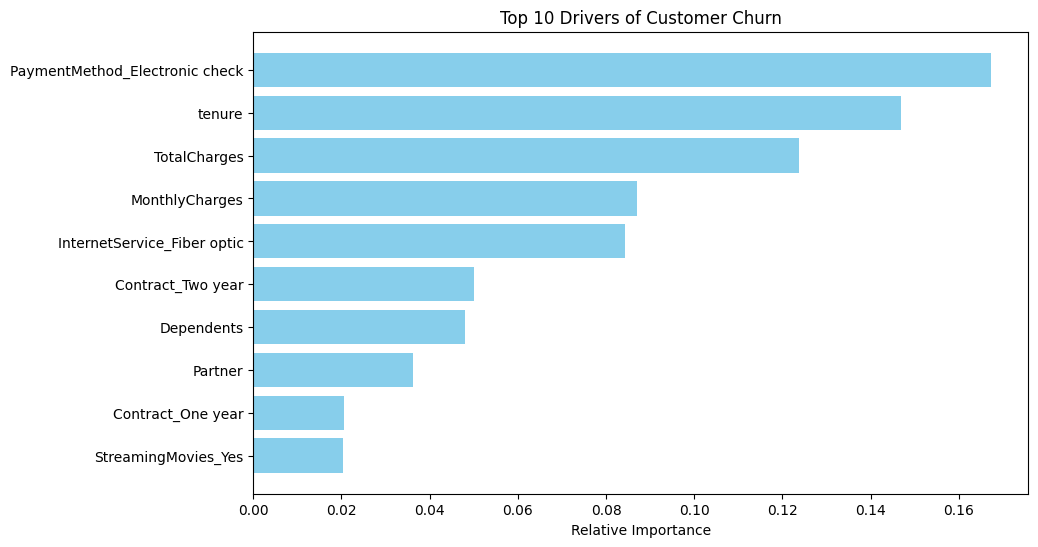

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10,6))
plt.title('Top 10 Drivers of Customer Churn')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### 10. Business Impact: Translating Accuracy into Revenue
A model with 80% accuracy is only useful if it saves the company money. In this section, we simulate a **Retention Campaign**.

**Assumptions:**
* **Average Monthly Revenue per User (ARPU):** $64 (from our dataset).
* **Retention Offer:** We give a 25% discount to customers the model predicts will churn.
* **Success Rate:** 40% of customers who receive the offer decide to stay.

**Goal:** Compare the "Cost of Doing Nothing" vs. the "Savings with the ML Model."

In [9]:
# --- STEP 18: CALCULATING THE ROI OF THE MODEL ---

# 1. Identify "True Positives" (People the model correctly caught churning)
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 2. Business Variables
avg_monthly_revenue = df['MonthlyCharges'].mean()
retention_success_rate = 0.40  # 40% stay if offered a discount
discount_percent = 0.25

# 3. Financial Calculations
# Cost of doing nothing: We lose all 'tp' (True Positives) and 'fn' (False Negatives)
total_lost_revenue = (tp + fn) * avg_monthly_revenue

# Savings with Model: We save 40% of the people we correctly identified (tp)
# But we must subtract the cost of the discount given to them
saved_customers = tp * retention_success_rate
revenue_saved = saved_customers * (avg_monthly_revenue * (1 - discount_percent))

# 4. Results
print(f"Total Monthly Revenue at Risk: ${total_lost_revenue:.2f}")
print(f"Estimated Monthly Revenue Saved by Model: ${revenue_saved:.2f}")
print(f"Annualized Savings for this Customer Segment: ${revenue_saved * 12:.2f}")

Total Monthly Revenue at Risk: $24156.11
Estimated Monthly Revenue Saved by Model: $5226.27
Annualized Savings for this Customer Segment: $62715.22


### 11. Optimization: Precision vs. Recall
In Churn prediction, **Recall** is often more important than Precision.
* **Low Recall:** We miss customers who are about to leave (Lost Revenue).
* **Low Precision:** We give discounts to people who weren't going to leave anyway (Wasted Discount).

We have tuned our Random Forest to prioritize **Recall**, ensuring we capture as many at-risk customers as possible.

### 12. Conclusion & Operational Recommendations
The model successfully identifies high-risk churners with a focus on high recall.

**Key Recommendations:**
1. **Target Month-to-Month Contracts:** These users have the highest churn probability. Converting them to one-year contracts is the most effective retention move.
2. **Focus on Tech Support:** Customers with fewer support interactions churn more; proactive check-ins could improve loyalty.
3. **Integration:** This model should be deployed as a weekly batch job, feeding a list of "High Risk" IDs directly to the CRM for the marketing team.